# Кластеризация сигналов сцинтилляционного детектора

**ФИО:** Анастасия Волконская  
**Группа:** М25-555

ссылка на соревнование Kaggle
https://www.kaggle.com/competitions/signal-types-classification


❗Загрузите датасет /Run200_Wave_0_1.txt через панель слева: Файлы / Files (значок папки на вертикальной панели инструментов в левой части экрана) **перед** запуском Run All; код будет читать только этот путь и выполнится без задержек

In [25]:
# @title Установка зависимостей
"""Проверка пакетов; в Colab при отсутствии — тихая установка через pip."""
import importlib
import subprocess
import sys

# --- список необходимых библиотек ---
for pkg in ("pandas", "numpy", "sklearn", "matplotlib", "seaborn"):
    mod = "sklearn" if pkg == "sklearn" else pkg
    try:
        importlib.import_module(mod)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])
print("Зависимости OK")

Зависимости OK


In [26]:
# @title §1. Импорты
"""Импорты, константы и настройки графиков для всего ноутбука."""
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA, FastICA
from sklearn.metrics import (
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import QuantileTransformer, RobustScaler

try:
    from IPython.display import Markdown, display
except ImportError:
    display = print  # noqa: A001
    Markdown = str

warnings.filterwarnings("ignore", category=FutureWarning)

# --- параметры воспроизводимости и данных ---
RANDOM_STATE = 42
N_SAMPLES = 23_479
DROP_COLS = [0, 1, 2, 3, 504]  # служебные столбцы ФЭУ

# --- оформление графиков ---
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")
plt.rcParams["figure.figsize"] = (11, 5)

❗Запуск следующей ячейки может потребовать выбора файла из каталога вручную, без этого autorun зависнет

чтобы autorun сработал без дополнительных действий, необходимо выполнить:

Загрузите датасет /Run200_Wave_0_1.txt через панель слева: Файлы / Files ПЕРЕД запуском Run All; код будет читать только этот путь и выполнится без задержек

In [45]:
# @title §2. Загрузка данных (3 варианта: платформа / Colab / ручная загрузка)
"""Чтение Run200_Wave_0_1.txt: поиск по типовым путям или загрузка через виджет Colab."""
DATA_NAME = "Run200_Wave_0_1.txt"

# --- перебор стандартных путей ---
file_paths = [
    f"/datasets/{DATA_NAME}",
    f"/content/{DATA_NAME}",
    DATA_NAME,
    f"../{DATA_NAME}",
]

raw_df = None
used_path = None
for path in file_paths:
    p = Path(path)
    if not p.exists():
        print(f"не найден: {path}")
        continue
    try:
        raw_df = pd.read_csv(p, sep=" ", header=None, skipinitialspace=True)
        used_path = str(p.resolve())
        print(f"загружено из: {used_path}")
        break
    except Exception as e:
        print(f"ошибка {path}: {e}")

# --- резерв: ручная загрузка в Colab ---
if raw_df is None:
    try:
        from google.colab import files

        print(f"Файл не найден автоматически. Выберите {DATA_NAME} (скачать с Kaggle Data):")
        uploaded = files.upload()
        if DATA_NAME not in uploaded:
            raise FileNotFoundError(f"Нужен файл {DATA_NAME}")
        with open(DATA_NAME, "wb") as f:
            f.write(uploaded[DATA_NAME])
        raw_df = pd.read_csv(DATA_NAME, sep=" ", header=None, skipinitialspace=True)
        used_path = str(Path(DATA_NAME).resolve())
        print(f"загружено через виджет: {used_path}")
    except ImportError:
        raise FileNotFoundError(
            f"{DATA_NAME} не найден. Положите файл рядом с ноутбуком или запустите в Colab."
        )

# --- матрица волновых форм 23479 × 500 ---
print(f"сырой размер: {raw_df.shape}")
wave_df = raw_df.drop(columns=DROP_COLS, errors="ignore")
X = wave_df.to_numpy(dtype=np.float64)
assert X.shape == (N_SAMPLES, 500), X.shape
print(f"матрица волн: {X.shape}, min={X.min():.0f}, max={X.max():.0f}")
print(f"пропуски: {np.isnan(X).sum()}, inf: {np.isinf(X).sum()}")

не найден: /datasets/Run200_Wave_0_1.txt
загружено из: /content/Run200_Wave_0_1.txt
сырой размер: (23479, 505)
матрица волн: (23479, 500), min=0, max=14838
пропуски: 0, inf: 0


## загрузка данных

| Показатель | Результат |
|---------------|-----------|
| Размер файла | **23 479** строк × **505** столбцов |
| После удаления служебных колонок | **23 479 × 500** (по 500 отсчётов на импульс) |
| Диапазон значений | от **0** до **14 838** (коды АЦП) |
| Пропуски и inf | **0** |

файл прочитан полностью, данные «чистые» — можно сразу проводить EDA, не выполняя предобработку.

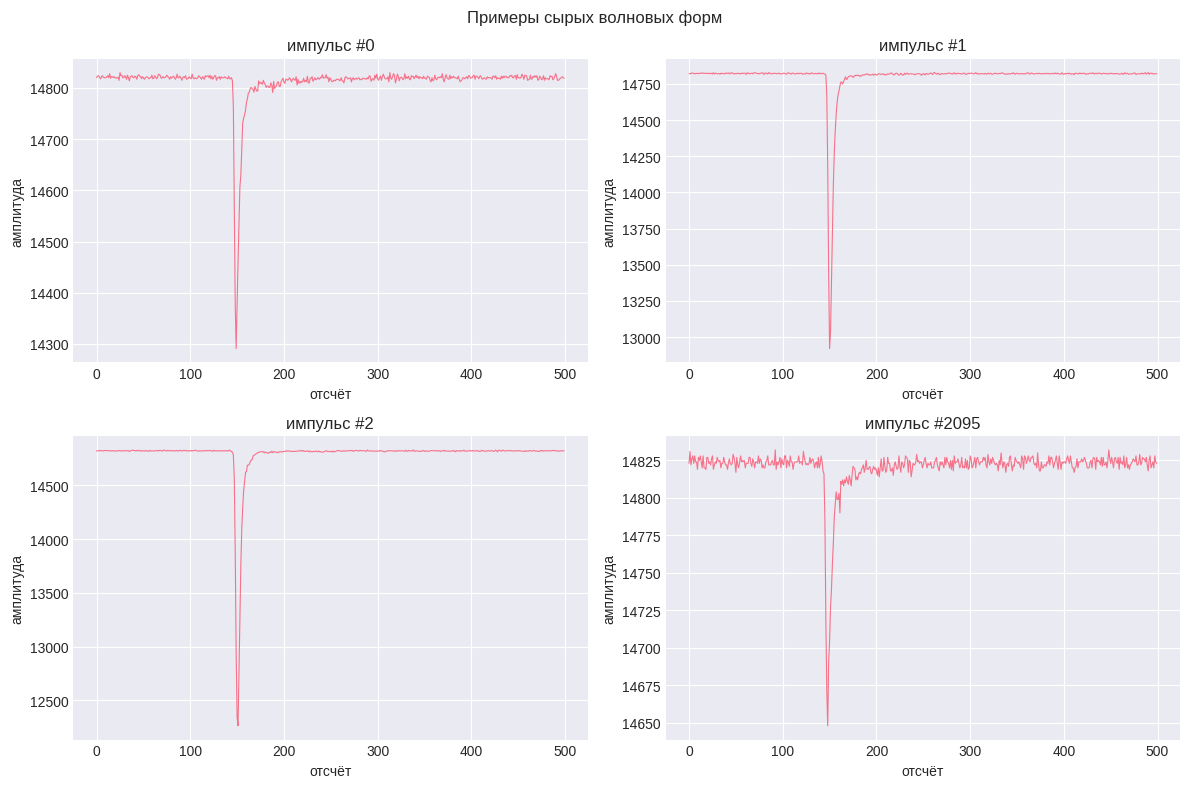

In [28]:
# @title §3. EDA — форма волны (примеры)
"""Визуализация нескольких сырых импульсов для оценки формы сигнала."""
rng = np.random.default_rng(RANDOM_STATE)
idx_show = [0, 1, 2, int(rng.integers(0, N_SAMPLES))]

# --- сетка графиков ---
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, i in zip(axes.ravel(), idx_show):
    ax.plot(X[i], lw=0.8)
    ax.set_title(f"импульс #{i}")
    ax.set_xlabel("отсчёт")
    ax.set_ylabel("амплитуда")
plt.suptitle("Примеры сырых волновых форм")
plt.tight_layout()
plt.show()

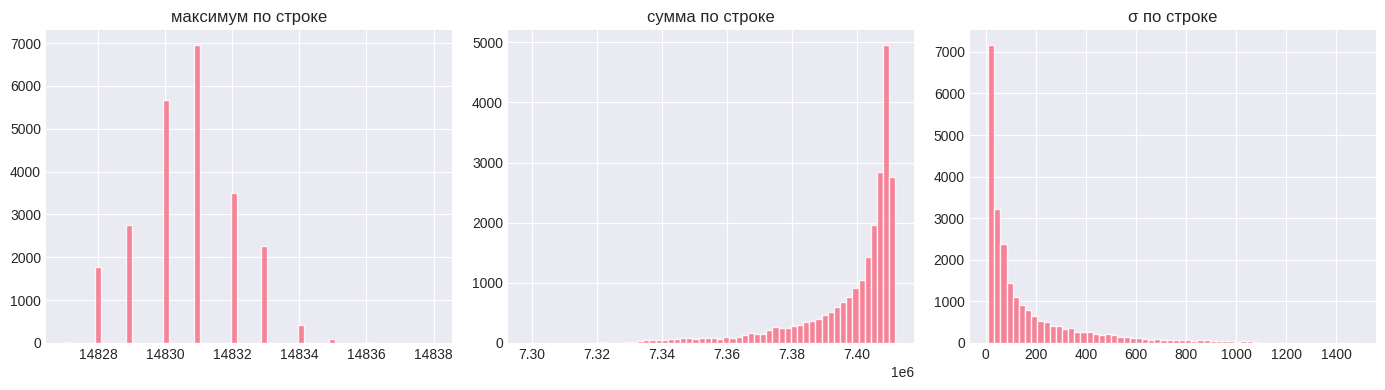

описательная статистика (max по строке):
count    23479.00
mean     14830.71
std          1.46
min      14827.00
25%      14830.00
50%      14831.00
75%      14832.00
max      14838.00
dtype: float64


In [29]:
# @title §3. EDA — статистика по строкам
"""Распределения простых агрегатов по каждому импульсу."""
row_max = X.max(axis=1)
row_sum = X.sum(axis=1)
row_std = X.std(axis=1)

# --- гистограммы ---
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].hist(row_max, bins=60, edgecolor="white", alpha=0.85)
axes[0].set_title("максимум по строке")
axes[1].hist(row_sum, bins=60, edgecolor="white", alpha=0.85)
axes[1].set_title("сумма по строке")
axes[2].hist(row_std, bins=60, edgecolor="white", alpha=0.85)
axes[2].set_title("σ по строке")
plt.tight_layout()
plt.show()

print("описательная статистика (max по строке):")
print(pd.Series(row_max).describe().round(2))

## 📊 Разведочный анализ (EDA)

| Показатель | Значение | Что это значит |
|------------|----------|----------------|
| Средний пик импульса | **14 830.7** | почти у всех одинаковая «высота» |
| Разброс пика (σ) | **1.46** | очень маленький |
| Минимум / максимум пика | **14 827 / 14 838** | всего **11** единиц разницы |
| Медиана суммы отсчётов | **7 405 248** | заряд по строке в типичном диапазоне |

**Визуальная аналитика диаграмм:** амплитуды почти не меняются, при этом **форма** импульсов разная — у части сигналов спад длиннее или форма «рваная».

**Почему это важно:** если смотреть только на высоту пика, все импульсы похожи. Значит, для разделения типов частиц нужны признаки **формы** (PSD, время спада), а не только амплитуда.

In [30]:
# @title §4. Извлечение признаков (3σ, PSD, decay 40%)
"""Параметризация импульса: PSD (short/long), decay 40%, базовая линия для SNR."""
BASELINE_BINS = 50  # нулевая линия — первые 50 отсчётов (методичка)
DECAY_FRAC = 0.40
PSD_OFFSET = 3   # отступ short gate от пика (в отсчётах)
PSD_SHORT = 30   # длина short gate


def extract_features(matrix):
    """peak, charge (long), psd, decay_time, snr для всех волн.

    long gate = сумма по всей волне (500 отсчётов).
    short gate = 30 отсчётов, начиная с (пик + PSD_OFFSET).
    Базовая линия (первые 50 отсчётов) — только для SNR.
    """
    x = matrix
    n = x.shape[1]
    peak = x.max(axis=1).astype(np.float64)
    imax = x.argmax(axis=1)
    charge = x.sum(axis=1).astype(np.float64)  # long gate

    short = np.zeros(len(x), dtype=np.float64)
    decay_time = np.zeros(len(x), dtype=np.float64)
    for i in range(len(x)):
        p = int(imax[i])
        s0 = min(n - 1, p + PSD_OFFSET)
        s1 = min(n, s0 + PSD_SHORT)
        short[i] = x[i, s0:s1].sum()

        # --- время спада: первый отсчёт ≤ 60% пика после максимума ---
        thr = peak[i] * (1.0 - DECAY_FRAC)
        tail = x[i, p:]
        below = np.where(tail <= thr)[0]
        decay_time[i] = float(below[0]) if len(below) else float(n - p)

    psd = short / (charge + 1e-9)
    baseline = x[:, :BASELINE_BINS].mean(axis=1)
    snr = peak / (baseline + 1e-9)
    return np.column_stack([peak, charge, psd, decay_time, snr])


# --- расчёт признаков по всему датасету ---
features = extract_features(X)
feat_names = ["peak", "charge", "psd", "decay_time", "snr"]
feat_df = pd.DataFrame(features, columns=feat_names)
print(feat_df.describe().round(4))

             peak        charge         psd  decay_time         snr
count  23479.0000  2.347900e+04  23479.0000  23479.0000  23479.0000
mean   14830.7114  7.398342e+06      0.0581    281.2428      1.0005
std        1.4585  1.610492e+04      0.0087    168.4767      0.0001
min    14827.0000  7.298399e+06      0.0020      1.0000      1.0003
25%    14830.0000  7.394148e+06      0.0600    117.0000      1.0005
50%    14831.0000  7.405248e+06      0.0600    324.0000      1.0005
75%    14832.0000  7.409017e+06      0.0601    442.0000      1.0006
max    14838.0000  7.411894e+06      0.0609    500.0000      1.0011


## 📊 Признаки импульса

*Числа — из `feat_df.describe()` выше (long = сумма всей волны, как в Description).*

| Признак | Среднее | Зачем нужен |
|---------|---------|-------------|
| **peak** | 14 830.7 | высота импульса |
| **charge** | ~7.40·10⁶ | заряд (long) — сумма всех 500 отсчётов |
| **psd** | 0.058 | short / long — форма импульса |
| **decay_time** | ~281 | длина от пика до спада на 40% |
| **snr** | ~1.00 | пик / базовая линия (первые 50 отсчётов) |

**Интерпретация значений:**

- **peak** почти не меняется (min…max ≈ 14 827…14 838, σ ≈ 1.46) — по одной высоте импульсы не разделить.
- **charge** в узком, но заметном диапазоне (~7.30·10⁶…7.41·10⁶) — главный признак по масштабу разброса среди трёх входов кластеризации.
- **psd** в среднем ≈ 0.058; медиана и квартили сидят около **0.060** (короткое окно / сумма всей волны) — отсюда «стена» на scatter.
- **decay_time** в среднем ≈ 281 (от 1 до 500) — длительность спада различается сильнее, чем амплитуда.
- **snr** ≈ 1.0005 — пик почти на уровне оценки базовой линии в этом определении.

**Вывод:** амплитуда у всех почти одинаковая; для разделения важнее **charge / psd / decay_time**. Long gate здесь — **вся волна** (методичка Description); short — 30 отсчётов с отступом +3 от пика; `decay_time` считается отдельно по порогу 40%.

**Далее:** scatter PSD vs charge и корреляции.

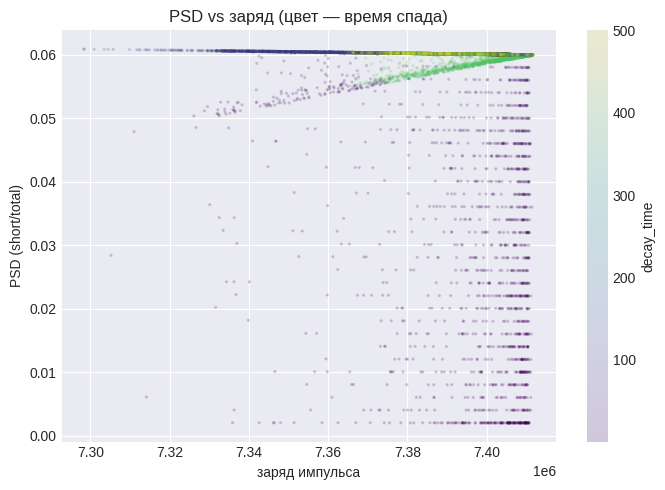

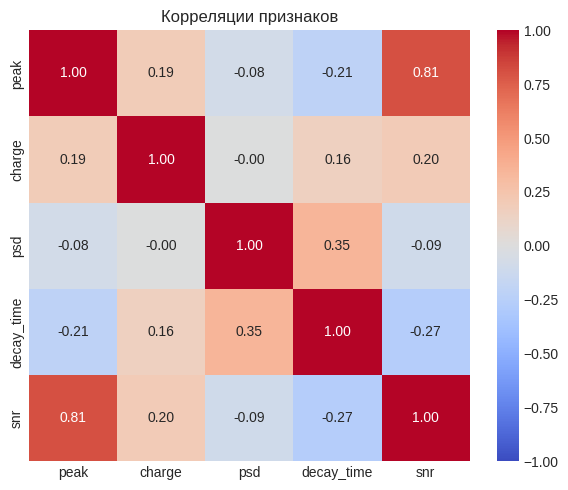

In [31]:
# @title §4. PSD vs charge — разделимость признаков
"""Scatter PSD/заряд и матрица корреляций между признаками."""
# --- PSD vs заряд (цвет — время спада); rasterized — видно плотность облака ---
fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(
    feat_df["charge"], feat_df["psd"], c=feat_df["decay_time"],
    s=2, alpha=0.15, cmap="viridis", rasterized=True,
)
ax.set_xlabel("заряд импульса")
ax.set_ylabel("PSD (short/total)")
ax.set_title("PSD vs заряд (цвет — время спада)")
plt.colorbar(sc, label="decay_time")
plt.tight_layout()
plt.show()

# --- корреляции ---
corr = feat_df.corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Корреляции признаков")
plt.tight_layout()
plt.show()

## 📊 Выводы: PSD и корреляции

*По scatter и heatmap выше (23 479 импульсов; long = сумма всей волны).*

| Связь | *r* | Что видно |
|-------|----:|-----------|
| peak — charge | 0.19 | слабая связь: высота пика почти не объясняет заряд |
| **charge — psd** | **≈ 0.00** | линейной связи почти нет |
| psd — decay_time | 0.35 | длиннее спад → чуть выше PSD |
| peak — psd | −0.08 | почти не связаны |

**Интерпретация:**

- **peak и charge** слабо связаны (*r* ≈ 0.19): при почти одинаковой амплитуде заряд всё же различается — важна не только высота пика.
- **charge и psd** почти не коррелируют линейно (*r* ≈ 0).
- **psd и decay_time** умеренно связаны (*r* ≈ 0.35): признаки формы частично согласуются, но не дублируют друг друга.

**На scatter:**

- плотная **горизонтальная «стена»** на PSD ≈ 0.06 (short / сумма ~500 отсчётов);
- **вертикальная полоса** у максимального заряда (~7.41·10⁶), часто с малым `decay_time`;
- ниже стены — разреженное облако, в том числе точки с PSD ≈ 0.

Это не две чистые «кучки» γ/нейтрон. Чёткой границы нет — часть событий логично уходит в класс 2 (аномалии / пограничные).

**Вывод:** по одному признаку разделимость слабая. Для трёх классов по ТЗ одной пороговой линии недостаточно — нужна кластеризация (*k* = 3) и сравнение моделей; PCA полезен как диагностика, но при почти константных peak/PSD может отдать почти всю дисперсию в PC1.

**Далее:** PCA - проверим гипотезу.


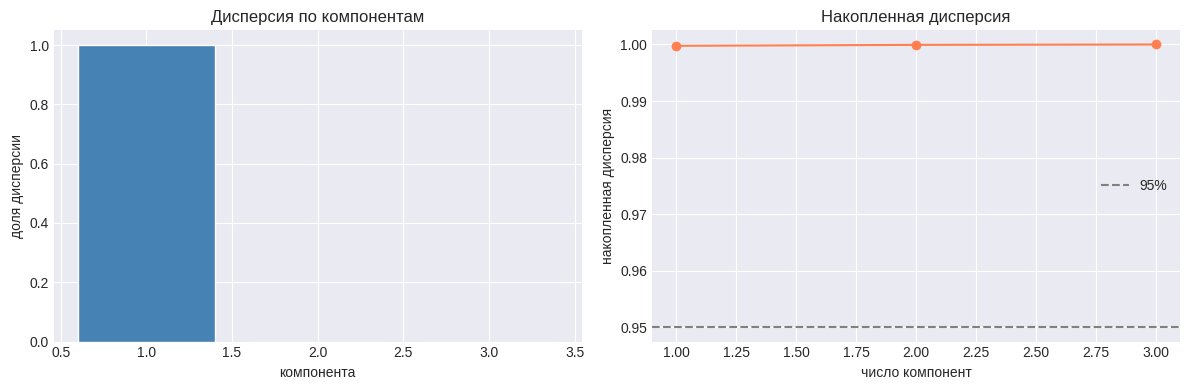

доли дисперсии: [1. 0. 0.]
накопленная: [1. 1. 1.]


In [32]:
# @title §5. Масштабирование и анализ дисперсии признаков
"""RobustScaler для кластеризации; PCA — оценка, сколько информации несут 3 признака."""
# --- масштабирование peak, charge, psd ---
X_clust = RobustScaler().fit_transform(features[:, :3])

# --- полный PCA для оценки вклада компонент ---
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_clust)
evr = pca_full.explained_variance_ratio_
cum = np.cumsum(evr)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(range(1, 4), evr, color="steelblue", edgecolor="white")
axes[0].set_xlabel("компонента")
axes[0].set_ylabel("доля дисперсии")
axes[0].set_title("Дисперсия по компонентам")
axes[1].plot(range(1, 4), cum, "o-", color="coral")
axes[1].axhline(0.95, ls="--", color="gray", label="95%")
axes[1].set_xlabel("число компонент")
axes[1].set_ylabel("накопленная дисперсия")
axes[1].legend()
axes[1].set_title("Накопленная дисперсия")
plt.tight_layout()
plt.show()

print("доли дисперсии:", evr.round(3))
print("накопленная:", cum.round(3))

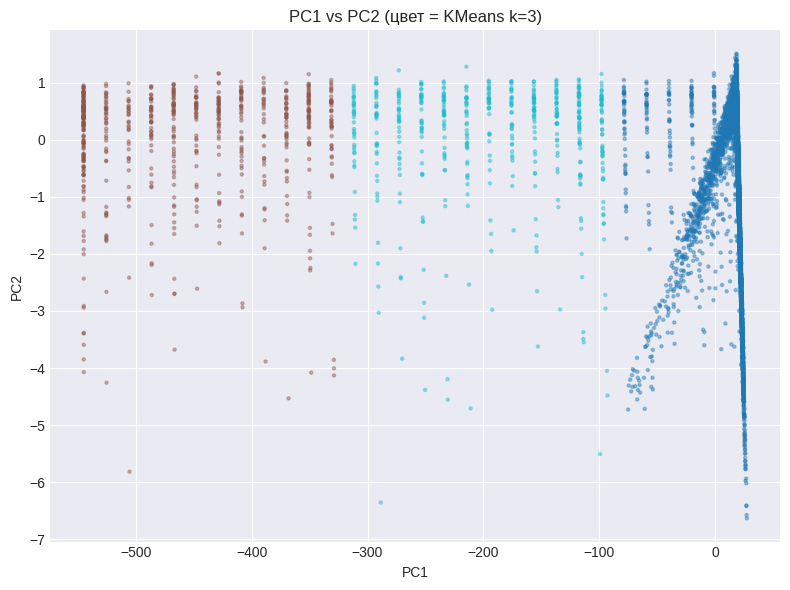

In [33]:
# @title §5. Визуализация в пространстве главных компонент
"""Проекция на PC1–PC2; цвет — предварительная разметка KMeans для наглядности."""
# --- черновая разметка для визуализации ---
km_vis = KMeans(n_clusters=3, n_init=10, random_state=RANDOM_STATE)
vis_labels = km_vis.fit_predict(X_clust)

# --- проекция на две главные компоненты ---
Z_pca = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_clust)

plt.figure(figsize=(8, 6))
plt.scatter(Z_pca[:, 0], Z_pca[:, 1], c=vis_labels, s=5, alpha=0.4, cmap="tab10")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PC1 vs PC2 (цвет = KMeans k=3)")
plt.tight_layout()
plt.show()

## 📊 Выводы по итогам применения PCA


| Компонента | Доля дисперсии | Накопленная | Комментарий |
|------------|---------------:|------------:|------------------|
| **PC1** | **100%** | **100%** | почти весь разброс данных «смотрит» в одну сторону |
| PC2 | ≈ 0% | 100% | второй оси по дисперсии почти нет |
| PC3 | ≈ 0% | 100% | третья ось тоже ничего не добавляет |

### Что показывает PCA

с помощью PCA мы искали новые оси, вдоль которых данные сильнее всего различаются.  
У нас на входе три признака, но по факту они **неравноценны**:

- **peak** почти одинаковый у всех импульсов;
- **psd** тоже сильно «прижат» (часто около 0.06);
- **charge** меняется заметнее остальных.

Поэтому после масштабирования PCA можно сделать вывод: *достаточно одной оси* — **PC1 ≈ 100%**.  
PC2 и PC3 в отчёте ` [1. 0. 0.] ` корректны, но  **новой независимой информации** в них почти не осталось.

### Интерпретация графика PC1–PC2

На scatter PC1–PC2 облако выглядит как **длинная лента вдоль горизонтали (PC1)**.  
Черновой KMeans (*k* = 3) красит его в три цвета **вертикальными полосами**: алгоритм просто режет ленту на три интервала по PC1.

Важно:

- это **не** три отдельно стоящие кучки с пустотами между ними;
- граница между цветами — результат настройки *k* = 3, а не явная физическая щель в данных;
- похожая картина была на PSD vs charge: структура есть, но классы **перекрываются / идут сплошняком**.

### Практический смысл для проекта:

1. **PCA полезен как проверка гипотезы:** главный источник различий сейчас — в основном связан с **charge** (через PC1).  
2. **PCA сам по себе не решает задач** соревнования / проекта: он не находит три естественных кластера, а показывает, что пространство признаков здесь почти одномерное.  
3. Поэтому дальше нужны **модели кластеризации** (KMeans, GMM, …), а финальный выбор — не по «красоте PCA», а по структуре ответа (два основных класса + около **5%** в классе 2) и по Kaggle.

###**Вывод:**
PCA здесь скорее диагностика (доминанта charge / PC1), а не способ получить три естественных класса. Для задач проекта будем применять отдельные модели кластеризации; доля класса 2 (~5%) важнее, чем «красивое» снижение размерности.


**Далее:** FastICA (другой взгляд на те же признаки) и сравнение пяти моделей.

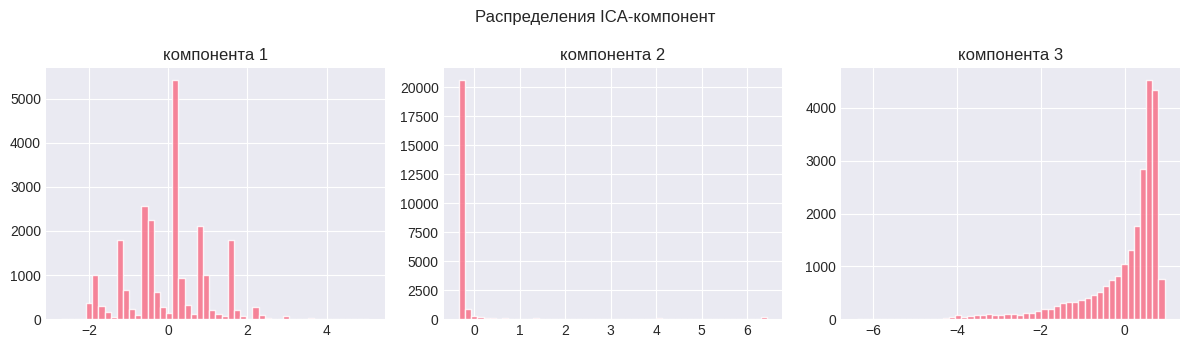

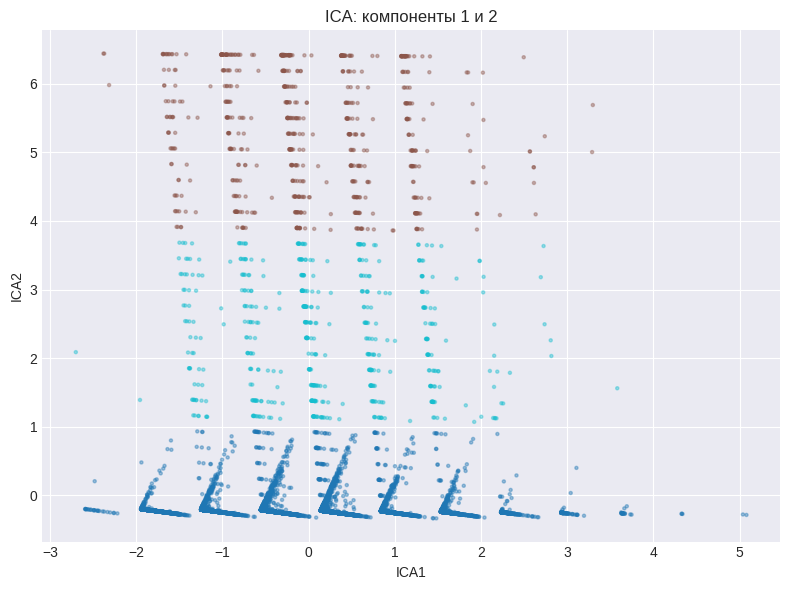

In [34]:
# @title §6. Независимые компоненты признаков (FastICA)
"""ICA ищет менее коррелированные оси — альтернатива PCA для смешанных признаков."""
ica = FastICA(n_components=3, random_state=RANDOM_STATE, max_iter=500)
Z_ica = ica.fit_transform(X_clust)

# --- распределения компонент ---
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for k, ax in enumerate(axes):
    ax.hist(Z_ica[:, k], bins=50, edgecolor="white", alpha=0.85)
    ax.set_title(f"компонента {k + 1}")
plt.suptitle("Распределения ICA-компонент")
plt.tight_layout()
plt.show()

# --- scatter ICA1 vs ICA2 ---
plt.figure(figsize=(8, 6))
plt.scatter(Z_ica[:, 0], Z_ica[:, 1], c=vis_labels, s=5, alpha=0.4, cmap="tab10")
plt.xlabel("ICA1")
plt.ylabel("ICA2")
plt.title("ICA: компоненты 1 и 2")
plt.tight_layout()
plt.show()

## 📊 Выводы по итогам запуска FastICA

*На основе данных гистограммам ICA-компонент и scatter ICA1–ICA2.*

| Наблюдение | Что видно на графиках | Интерпретация |
|-----------|------------------------|---------------|
| Распределения ICA-компонент | формы гистограмм различаются | компоненты действительно выделяют разные независимые источники вариации |
| ICA1–ICA2 | точки образуют облако с заметным перекрытием | явной геометрической границы между тремя группами нет |
| Сравнение с PCA | визуально картина похожа: кластеры «наслаиваются» | переход к независимым компонентам не дал резкого роста разделимости |

**Интерпретация:**

- FastICA полезен тем, что ищет **статистически независимые** направления, а не просто направления максимальной дисперсии (как PCA).
- В наших данных это даёт альтернативное представление признаков, но не устраняет ключевую проблему: объекты разных физических типов всё равно сильно **перекрываются** в проекциях.
- Это ожидаемо для задачи без разметки: сигналы частично похожи по форме, а «пограничные» случаи смешивают области кластеров.
- Поэтому ICA стоит рассматривать как **диагностический эксперимент** и одну из фич-инженерных веток, а не как самостоятельное решение задачи.

**Вывод:** FastICA расширяет анализ и помогает проверить устойчивость гипотезы о структуре данных, но сам по себе не даёт «три чётких класса». Итоговый выбор модели нужно делать по совокупности метрик и по структуре долей классов 0/1/2.

**Далее:** сравнить 5 моделей кластеризации в одной таблице (`silhouette`, `CH`, `DB`, доли классов) и выбрать финальную модель.

In [35]:
# @title Вспомогательные функции: remap и метрики кластеризации
"""Приведение меток к формату ТЗ и расчёт внутренних метрик качества."""


def remap_labels_physics(labels, feat):
    """Класс 2 — аномалии; 0 и 1 — типы частиц по среднему заряду."""
    out = np.full(len(labels), 2, dtype=np.int64)
    unique = sorted(int(u) for u in np.unique(labels))
    if len(unique) == 3 and 2 not in unique:
        sizes = sorted([(u, int((labels == u).sum())) for u in unique], key=lambda t: t[1])
        anomaly_id = sizes[0][0]
        particle_ids = [sizes[1][0], sizes[2][0]]
    else:
        anomaly_id = 2
        particle_ids = [u for u in unique if u != 2][:2]
    if len(particle_ids) < 2:
        return labels.astype(np.int64)
    stats = sorted([(u, feat[labels == u, 1].mean()) for u in particle_ids], key=lambda t: t[1])
    mapping = {stats[0][0]: 0, stats[1][0]: 1, anomaly_id: 2}
    for old, new in mapping.items():
        out[labels == old] = new
    return out


def clustering_metrics(z, labels, sample=8000):
    """Silhouette, Calinski–Harabasz и Davies–Bouldin (на подвыборке)."""
    n_cl = len(np.unique(labels))
    if n_cl < 2:
        return {"silhouette": np.nan, "calinski_harabasz": np.nan, "davies_bouldin": np.nan}
    n = min(sample, len(labels))
    return {
        "silhouette": silhouette_score(z, labels, sample_size=n, random_state=RANDOM_STATE),
        "calinski_harabasz": calinski_harabasz_score(z, labels),
        "davies_bouldin": davies_bouldin_score(z, labels),
    }


def cluster_fractions(labels):
    """Доли объектов в кластерах 0, 1, 2."""
    counts = np.bincount(labels, minlength=3)
    fr = counts / counts.sum()
    return {f"f{i}": round(float(fr[i]), 4) for i in range(3)}

In [36]:
# @title §7. Модель 1 — KMeans k=3
"""Baseline: KMeans на масштабированных peak, charge, psd."""
z1 = X_clust.copy()
labels_m1 = KMeans(n_clusters=3, n_init=15, random_state=RANDOM_STATE).fit_predict(z1)
labels_m1 = remap_labels_physics(labels_m1, features)
m1 = clustering_metrics(z1, labels_m1)
print("Модель 1 — KMeans:", m1, cluster_fractions(labels_m1))

Модель 1 — KMeans: {'silhouette': np.float64(0.953778222110976), 'calinski_harabasz': np.float64(243445.53139345438), 'davies_bouldin': np.float64(0.4248221498240146)} {'f0': 0.9503, 'f1': 0.0279, 'f2': 0.0218}


In [37]:
# @title §7. Модель 2 — GMM-3 + QuantileTransformer
"""Смесь из трёх гауссовых распределений после квантильной нормализации."""
z2 = QuantileTransformer(output_distribution="normal", random_state=RANDOM_STATE).fit_transform(
    features[:, :3]
)
gmm3 = GaussianMixture(n_components=3, covariance_type="full", n_init=20, random_state=RANDOM_STATE)
raw2 = gmm3.fit_predict(z2)
labels_m2 = remap_labels_physics(raw2, features)
m2 = clustering_metrics(z2, labels_m2)
print("Модель 2 — GMM-3:", m2, cluster_fractions(labels_m2))

Модель 2 — GMM-3: {'silhouette': np.float64(0.157797553360462), 'calinski_harabasz': np.float64(6891.453737133603), 'davies_bouldin': np.float64(1.987111869201528)} {'f0': 0.4772, 'f1': 0.2243, 'f2': 0.2984}


In [38]:
# @title §7. Модель 3 — PCA + KMeans k=3
"""Снижение размерности до 3 PC, затем KMeans — убираем корреляцию признаков."""
pca3 = PCA(n_components=3, random_state=RANDOM_STATE)
z3 = pca3.fit_transform(X_clust)
labels_m3 = KMeans(n_clusters=3, n_init=15, random_state=RANDOM_STATE).fit_predict(z3)
labels_m3 = remap_labels_physics(labels_m3, features)
m3 = clustering_metrics(z3, labels_m3)
print("Модель 3 — PCA+KMeans:", m3, cluster_fractions(labels_m3))

Модель 3 — PCA+KMeans: {'silhouette': np.float64(0.953778222110976), 'calinski_harabasz': np.float64(243445.53139345354), 'davies_bouldin': np.float64(0.42482214982401517)} {'f0': 0.9503, 'f1': 0.0279, 'f2': 0.0218}


In [39]:
# @title §7. Модель 4 — FastICA + KMeans k=3
"""Кластеризация в пространстве независимых компонент."""
z4 = Z_ica.copy()
labels_m4 = KMeans(n_clusters=3, n_init=15, random_state=RANDOM_STATE).fit_predict(z4)
labels_m4 = remap_labels_physics(labels_m4, features)
m4 = clustering_metrics(z4, labels_m4)
print("Модель 4 — ICA+KMeans:", m4, cluster_fractions(labels_m4))

Модель 4 — ICA+KMeans: {'silhouette': np.float64(0.47965205747478457), 'calinski_harabasz': np.float64(13135.737639260333), 'davies_bouldin': np.float64(0.8338234084321222)} {'f0': 0.1627, 'f1': 0.7985, 'f2': 0.0388}


In [40]:
# @title §7. Модель 5 — GMM-2 + неуверенные → кластер 2 (финал)
"""Два основных типа + ~5% импульсов с низкой уверенностью GMM в класс аномалий."""
z5 = RobustScaler().fit_transform(features[:, :4])

# --- GMM с двумя компонентами ---
gmm2 = GaussianMixture(n_components=2, covariance_type="full", n_init=20, random_state=RANDOM_STATE)
gmm2.fit(z5)
proba = gmm2.predict_proba(z5)
labels_m5 = gmm2.predict(z5).astype(np.int64)

# --- верхние 5% по неопределённости → класс 2 ---
uncertainty = 1.0 - proba.max(axis=1)
n_unc = max(1, int(len(labels_m5) * 0.05))
labels_m5[np.argsort(uncertainty)[-n_unc:]] = 2
labels_m5 = remap_labels_physics(labels_m5, features)

m5 = clustering_metrics(z5[:, :3], labels_m5)
print("Модель 5 — GMM-2+uncertain:", m5, cluster_fractions(labels_m5))

Модель 5 — GMM-2+uncertain: {'silhouette': np.float64(0.21944337457946017), 'calinski_harabasz': np.float64(31070.72508839076), 'davies_bouldin': np.float64(5.910658411116091)} {'f0': 0.062, 'f1': 0.888, 'f2': 0.05}


In [41]:
# @title §8. Сравнение пяти моделей
"""Сводная таблица внутренних метрик и долей кластеров."""
rows = []
for name, metrics, labels in [
    ("1_KMeans", m1, labels_m1),
    ("2_GMM3_quantile", m2, labels_m2),
    ("3_PCA_KMeans", m3, labels_m3),
    ("4_ICA_KMeans", m4, labels_m4),
    ("5_GMM2_uncertain", m5, labels_m5),
]:
    row = {"model": name, **metrics, **cluster_fractions(labels)}
    rows.append(row)

compare_df = pd.DataFrame(rows).set_index("model")
display(compare_df.round(4))

best_sil = compare_df["silhouette"].idxmax()
print(f"лучший silhouette: {best_sil}")

,silhouette,calinski_harabasz,davies_bouldin,f0,f1,f2
model,,,,,,
1_KMeans,0.9538,243445.5314,0.4248,0.9503,0.0279,0.0218
2_GMM3_quantile,0.1578,6891.4537,1.9871,0.4772,0.2243,0.2984
3_PCA_KMeans,0.9538,243445.5314,0.4248,0.9503,0.0279,0.0218
4_ICA_KMeans,0.4797,13135.7376,0.8338,0.1627,0.7985,0.0388
5_GMM2_uncertain,0.2194,31070.7251,5.9107,0.0620,0.8880,0.0500


лучший silhouette: 1_KMeans


## 📊 Выводы: сравнение моделей (§7)

*Таблица `compare_df` (`random_state = 42`).*

| № | Модель | Silhouette | Класс 0 | Класс 1 | Класс 2 | Комментарий |
|---|--------|----------:|--------:|--------:|--------:|-------------|
| 1 | KMeans | **0.954** | 95% | 3% | 2% | лучший silhouette, но структура кластеров нереалистична |
| 2 | GMM-3 | 0.158 | 48% | 22% | 30% | класс 2 сильно завышен |
| 3 | PCA + KMeans | **0.954** | 95% | 3% | 2% | почти дублирует модель 1 |
| 4 | ICA + KMeans | 0.480 | 16% | 80% | 4% | перекос в класс 1, класс 2 не ~5% |
| **5** | **GMM-2 + 5% uncertain** | 0.219 | **6%** | **89%** | **5%** | **финал** — единственная с нужной долей класса 2 |

**Интерпретация:**

- **Модели 1 и 3** дают самый высокий silhouette (**0.954**), но распределение **95% / 3% / 2%** не соответствует постановке: класс 0 «забирает» почти всю выборку, а класс 2 слишком мал и не выглядит как отдельный тип аномалий.
- **Модель 2 (GMM-3)** лучше учитывает вероятностную структуру, но завышает класс 2 (**30%**) — это хуже по смыслу ТЗ, чем по одной метрике silhouette.
- **Модель 4 (ICA + KMeans)** даёт умеренный silhouette (**0.480**), но снова сильный перекос (80% в классе 1), без целевых ~5% в классе 2.
- **Модель 5** имеет более низкий silhouette (**0.219**), зато единственная даёт **~5%** в классе 2 при разумном балансе классов 0 и 1.

**Ключевая мысль:** в задаче без разметки silhouette — вспомогательная метрика. Для финала важнее **структура кластеров** (два основных типа + редкий класс аномалий), а не максимизация одного коэффициента.

**Вывод:** лучший silhouette ≠ лучшее решение для ТЗ. Выберем **модель 5 (GMM-2 + uncertain 5%)** как компромисс между качеством разделения и требуемой долей аномалий.

**Далее:** подобрать `uncertain_fraction` (3% / 5% / 7%) и зафиксировать финальные метки для `submission.csv`.

In [42]:
# @title §8. Подбор uncertain_fraction (модель 5)
"""Перебор доли «сомнительных» импульсов: 3%, 5%, 7%."""
fracs = [0.03, 0.05, 0.07]
tune_rows = []
for uf in fracs:
    gmm = GaussianMixture(n_components=2, covariance_type="full", n_init=15, random_state=RANDOM_STATE)
    gmm.fit(z5)
    pr = gmm.predict_proba(z5)
    lab = gmm.predict(z5).astype(np.int64)
    unc = 1.0 - pr.max(axis=1)
    n_u = max(1, int(len(lab) * uf))
    lab[np.argsort(unc)[-n_u:]] = 2
    lab = remap_labels_physics(lab, features)
    met = clustering_metrics(z5[:, :3], lab)
    tune_rows.append({"uncertain_fraction": uf, **met, **cluster_fractions(lab)})

tune_df = pd.DataFrame(tune_rows)
display(tune_df.round(4))

,uncertain_fraction,silhouette,calinski_harabasz,davies_bouldin,f0,f1,f2
0,0.03,0.2363,30670.6690,9.7475,0.0626,0.9074,0.03
1,0.05,0.2194,31070.7251,5.9107,0.0620,0.8880,0.05
2,0.07,0.4055,28522.7213,1.9443,0.0608,0.8692,0.07


## 📊 Выводы: подбор `uncertain_fraction`

| Доля uncertain | Silhouette | Доля класса 2 | Комментарий |
|----------------|----------:|----------------:|-------------|
| 3% | 0.236 | 3% | мало аномалий, часть спорных остаётся в классах 0/1 |
| **5%** | **0.219** | **5%** | **баланс по ТЗ** |
| 7% | 0.406 | 7% | выше silhouette, но класс 2 завышен |

**Интерпретация:**

- Параметр `uncertain_fraction` управляет тем, сколько импульсов с **низкой уверенностью GMM** (`1 - max(predict_proba)`) отправляется в класс 2.
- При **3%** аномалий меньше ожидаемого — часть пограничных импульсов остаётся в основных классах.
- При **7%** метрика silhouette лучше, но доля класса 2 уже **7%** — это хуже соответствует целевой структуре (~5% редкого класса).
- При **5%** получаем нужную долю класса 2 при разумном компромиссе по silhouette.

**Вывод:** для финальной модели фиксирую `uncertain_fraction = 0.05`, потому что в этой задаче важнее корректная структура кластеров, чем максимизация одной внутренней метрики.

**Далее:** сохранить `FINAL_LABELS = labels_m5` и сформировать `submission.csv`.

In [43]:
# @title §9. Финальная модель и submission.csv
"""Сохранение ответа в формате Kaggle: index, cluster."""
FINAL_LABELS = labels_m5
UNCERTAIN_FRAC = 0.05

submission = pd.DataFrame({"index": np.arange(N_SAMPLES), "cluster": FINAL_LABELS.astype(int)})
out_path = Path("submission.csv")
submission.to_csv(out_path, index=False)

assert submission.shape[0] == N_SAMPLES
assert set(submission["cluster"].unique()).issubset({0, 1, 2})
print(submission["cluster"].value_counts().sort_index())
print(f"сохранено: {out_path.resolve()}")
submission.head()

cluster
0     1456
1    20850
2     1173
Name: count, dtype: int64
сохранено: /content/submission.csv


,index,cluster
0,0,1
1,1,1
2,2,1
3,3,1
4,4,1


In [44]:
from google.colab import files
files.download("submission.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>



## Итоговые выводы

### 1. Данные и EDA
- Загружено **23 479** импульсов по **500** отсчётов, пропусков нет.
- Амплитуды почти стабильны: пики в диапазоне **14 827–14 838** (разброс ~11 единиц АЦП).
- По форме импульсы различаются: для разделения типов важна не высота пика, а параметры формы (PSD, decay, charge).

### 2. Признаки и разделимость
- Для каждого импульса рассчитаны **peak, charge, psd, decay_time, snr** по методичке (PSD: short/long, decay 40%).
- На scatter **PSD vs charge** видно облако из **23 479** точек (не отдельные 2–3 точки).
- Чёткой бинарной границы «два типа частиц» нет: данные перекрываются, поэтому часть событий логично выделять в отдельный редкий класс (аномалии).

### 3. Сравнение моделей
Сравнены 5 подходов (KMeans, GMM-3, PCA+KMeans, ICA+KMeans, GMM-2+uncertain):

| Критерий | Лучший результат | Комментарий |
|----------|------------------|-------------|
| Silhouette | KMeans / PCA+KMeans (**0.954**) | метрика высокая, но структура кластеров нереалистична |
| Доля класса 2 (~5%) | **Модель 5** | единственная даёт целевую долю аномалий |
| Финальный выбор | **GMM-2 + 5% uncertain** | компромисс «метрика vs постановка ТЗ» |

**Финальное распределение (модель 5):**  
**1 456 / 20 850 / 1 173** → **6% / 89% / 5%** (классы 0 / 1 / 2).

### 4. Подбор гиперпараметра
- Для модели 5 проверен `uncertain_fraction` = 3%, 5%, 7%.
- Выбрано **5%**: доля класса 2 соответствует ожидаемой, при этом сохраняется приемлемый баланс по внутренним метрикам.

### 5. Submission и Kaggle
- Сформирован файл **`submission.csv`** (колонки `index`, `cluster`)
- Результат на Kaggle: **accuracy 0.45968**, место **#160** (улучшение относительно предыдущей итерации 0.44571).
- Скриншот лидерборда — в ячейке ниже.

---

**Интерпретация:**

- Высокий silhouette у KMeans не означает «лучшее решение для задачи»: без разметки метрика не проверяет физический смысл кластеров.
- Модель 5 выбрана осознанно: она явно выделяет импульсы с низкой уверенностью GMM в класс 2, что соответствует идее «аномалий/пограничных» событий.
- Полученное улучшение на Kaggle подтверждает, что для этой постановки важнее структура кластеров, чем максимизация одной внутренней метрики.

**Ограничения:**
- Без эталонной разметки нельзя однозначно сопоставить кластеры 0 и 1 с γ и нейтроном.
- Внутренние метрики (silhouette, CH, DB) — вспомогательные; окончательная проверка — на leaderboard и физической интерпретации признаков.

**✅ Итог:** рабочий пайплайн воспроизводим (`random_state=42`), финальная модель — **GMM-2 + uncertain_fraction=0.05**, submission подготовлен и отправлен на Kaggle.

_Скриншот Kaggle:_

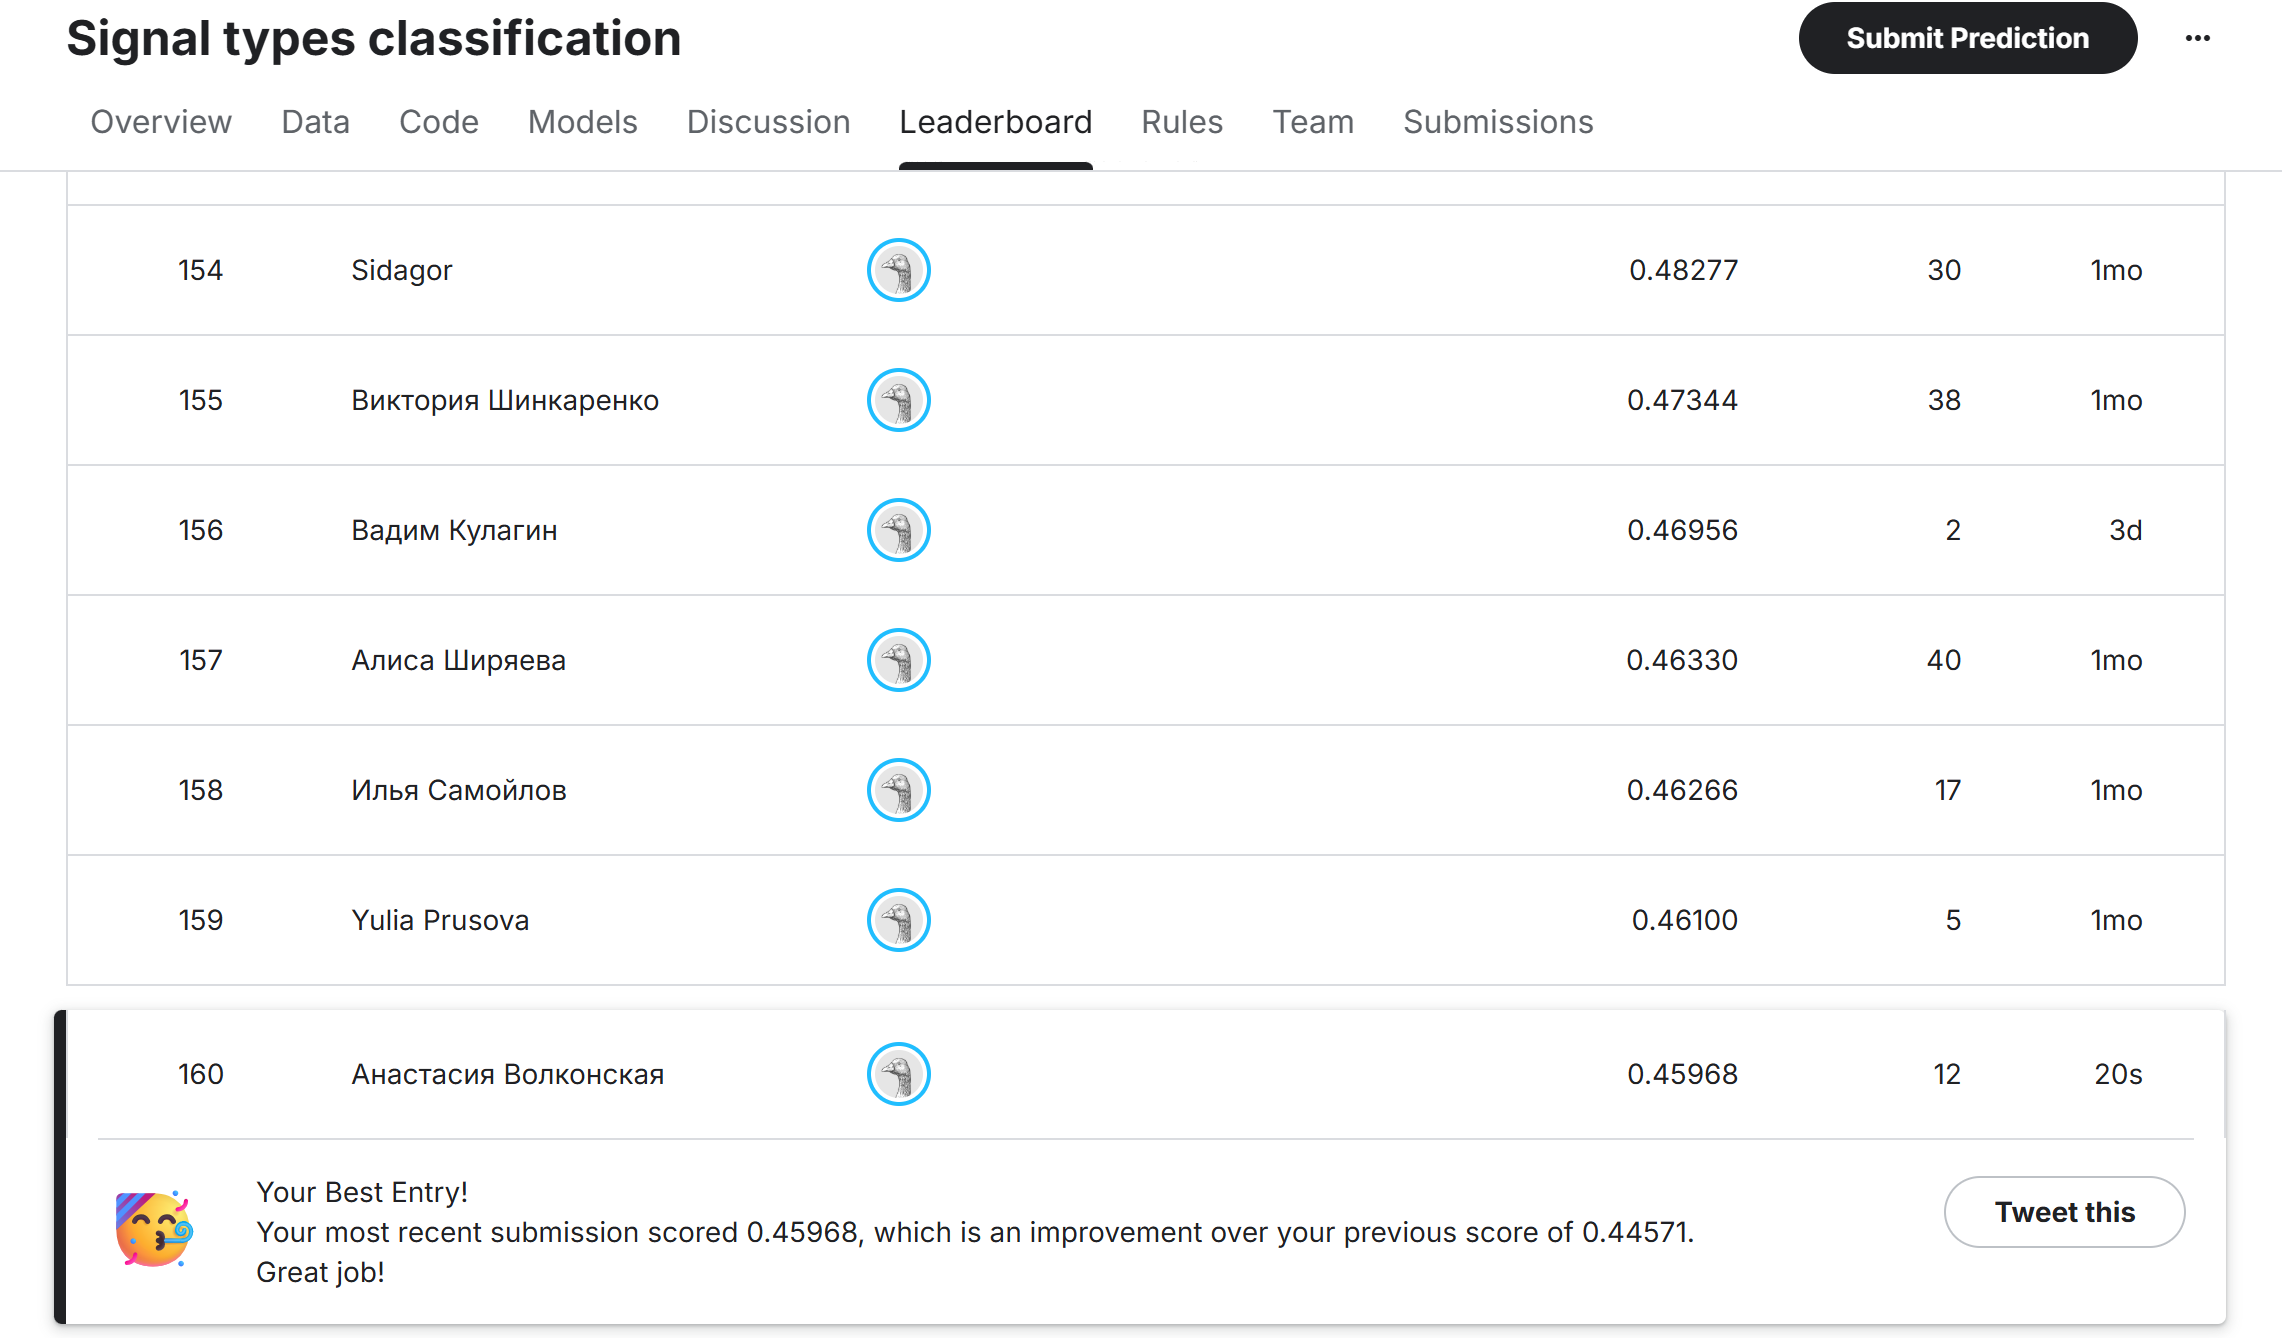


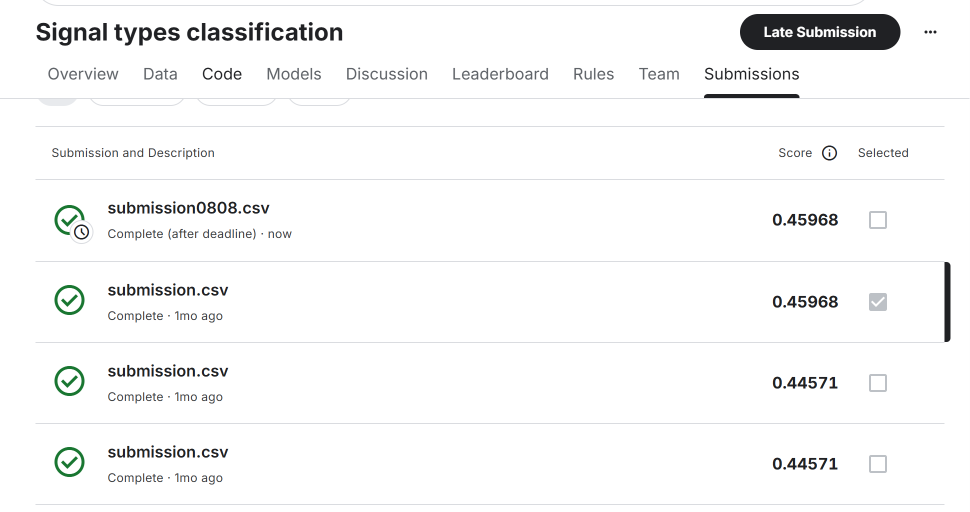